# Análise de Dados de E-commerce por Guilherme Daflon Goulart Costa

## Contexto do Problema

Você recebeu duas bases de dados de um comércio eletrônico:
- **vendas:** histórico de transações com valores, categorias, datas e status.
- **clientes:** cadastro com o identificador do cliente, nome e cidade.

Seu objetivo como analista é tratar os dados ausentes, cruzar as bases, extrair métricas de negócio e preparar a base para relatórios gerenciais.

### Dados para Configuração do Ambiente.
Execute o bloco abaixo para criar os DataFrames iniciais para o exercício:

In [11]:
import numpy as np
import pandas as pd

# Base de vendas
dados_vendas = {
    'cliente_id': [101, 102, 103, 101, 104, 102, 105, 103],
    'valor': [3500.75, 189.50, np.nan, 1200.00, 450.00, np.nan, 89.90, 780.50],
    'categoria': [
        'Eletronicos',
        'Livros',
        'Roupas',
        'Eletronicos',
        'Automotivo',
        'Livros',
        'Roupas',
        'Roupas',
    ],
    'data_hora': [
        '2024-01-15 10:23:00',
        '2024-01-18 14:05:00',
        '2024-02-05 09:12:00',
        '2024-02-20 16:40:00',
        '2024-03-02 11:00:00',
        '2024-03-15 18:30:00',
        '2024-04-10 08:20:00',
        '2024-04-22 13:45:00',
    ],
    'status': [
        'Concluído',
        'Concluído',
        'Pendente',
        'Concluído',
        'Cancelado',
        'Concluído',
        'Concluído',
        'Concluído',
    ],
    'email': [
        'maria@gmail.com',
        'joao@outlook.com',
        'ana@yahoo.com',
        'maria@gmail.com',
        'carlos@gmail.com',
        'joao@outlook.com',
        'lucas@empresa.com.br',
        'ana@yahoo.com',
    ],
}

# Base de clientes
dados_clientes = {
    'cliente_id': [101, 102, 103, 104, 105],
    'nome': [
        'Maria Silva',
        'Joao Souza',
        'Ana Oliveira',
        'Carlos Lima',
        'Lucas Mendes',
    ],
    'cidade': [
        'Sao Paulo',
        'Rio de Janeiro',
        'Belo Horizonte',
        'Curitiba',
        'Salvador',
    ],
}

df_vendas = pd.DataFrame(dados_vendas)
df_clientes = pd.DataFrame(dados_clientes)

print("DataFrames `df_vendas` and `df_clientes` created successfully.")


DataFrames `df_vendas` and `df_clientes` created successfully.


## Tarefas do Exercício

### Parte 1: Diagnóstico e Limpeza (Básico)

In [12]:
# 1. Inspecione as dimensões e o resumo dos tipos de dados do DataFrame df_vendas
print("Dimensões de df_vendas:", df_vendas.shape)
print("\nInformações de df_vendas:")
df_vendas.info()


Dimensões de df_vendas: (8, 6)

Informações de df_vendas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cliente_id  8 non-null      int64  
 1   valor       6 non-null      float64
 2   categoria   8 non-null      object 
 3   data_hora   8 non-null      object 
 4   status      8 non-null      object 
 5   email       8 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 516.0+ bytes


In [13]:
# 2. Identifique os valores nulos e preencha os registros ausentes da coluna 'valor'
print("\nValores nulos antes do preenchimento:")
print(df_vendas.isnull().sum())

# Preencher valores nulos de 'valor' com a mediana da respectiva categoria
df_vendas['valor'] = df_vendas.groupby('categoria')['valor'].transform(lambda x: x.fillna(x.median()))

# Se ainda houver nulos (para categorias sem valor), preencher com a mediana global
df_vendas['valor'].fillna(df_vendas['valor'].median(), inplace=True)

print("\nValores nulos depois do preenchimento:")
print(df_vendas.isnull().sum())
display(df_vendas)



Valores nulos antes do preenchimento:
cliente_id    0
valor         2
categoria     0
data_hora     0
status        0
email         0
dtype: int64

Valores nulos depois do preenchimento:
cliente_id    0
valor         0
categoria     0
data_hora     0
status        0
email         0
dtype: int64


/tmp/ipykernel_4123/2547999702.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_vendas['valor'].fillna(df_vendas['valor'].median(), inplace=True)


,cliente_id,valor,categoria,data_hora,status,email
0,101,3500.75,Eletronicos,2024-01-15 10:23:00,Concluído,maria@gmail.com
1,102,189.50,Livros,2024-01-18 14:05:00,Concluído,joao@outlook.com
2,103,435.20,Roupas,2024-02-05 09:12:00,Pendente,ana@yahoo.com
3,101,1200.00,Eletronicos,2024-02-20 16:40:00,Concluído,maria@gmail.com
4,104,450.00,Automotivo,2024-03-02 11:00:00,Cancelado,carlos@gmail.com
5,102,189.50,Livros,2024-03-15 18:30:00,Concluído,joao@outlook.com
6,105,89.90,Roupas,2024-04-10 08:20:00,Concluído,lucas@empresa.com.br
7,103,780.50,Roupas,2024-04-22 13:45:00,Concluído,ana@yahoo.com


In [14]:
# 3. Filtre e exiba apenas as transações com status 'Concluído' e valor superior a R$ 500,00

transacoes_filtradas = df_vendas.loc[(df_vendas['status'] == 'Concluído') & (df_vendas['valor'] > 500.00)]
# Alternativamente, usando .query():
# transacoes_filtradas = df_vendas.query("status == 'Concluído' and valor > 500.00")

print("\nTransações com status 'Concluído' e valor superior a R$ 500,00:")
display(transacoes_filtradas)



Transações com status 'Concluído' e valor superior a R$ 500,00:


,cliente_id,valor,categoria,data_hora,status,email
0,101,3500.75,Eletronicos,2024-01-15 10:23:00,Concluído,maria@gmail.com
3,101,1200.00,Eletronicos,2024-02-20 16:40:00,Concluído,maria@gmail.com
7,103,780.50,Roupas,2024-04-22 13:45:00,Concluído,ana@yahoo.com


### Parte 2: Cruzamento e Transformação (Intermediário)

In [15]:
# 4. Realize uma junção relacional (left merge) entre df_vendas e df_clientes

df_merged = pd.merge(df_vendas, df_clientes, on='cliente_id', how='left')

print("\nDataFrame após o merge:")
display(df_merged.head())



DataFrame após o merge:


,cliente_id,valor,categoria,data_hora,status,email,nome,cidade
0,101,3500.75,Eletronicos,2024-01-15 10:23:00,Concluído,maria@gmail.com,Maria Silva,Sao Paulo
1,102,189.50,Livros,2024-01-18 14:05:00,Concluído,joao@outlook.com,Joao Souza,Rio de Janeiro
2,103,435.20,Roupas,2024-02-05 09:12:00,Pendente,ana@yahoo.com,Ana Oliveira,Belo Horizonte
3,101,1200.00,Eletronicos,2024-02-20 16:40:00,Concluído,maria@gmail.com,Maria Silva,Sao Paulo
4,104,450.00,Automotivo,2024-03-02 11:00:00,Cancelado,carlos@gmail.com,Carlos Lima,Curitiba


In [16]:
# 5. Crie uma nova coluna 'media_categoria' com o valor médio de vendas por categoria

df_merged['media_categoria'] = df_merged.groupby('categoria')['valor'].transform('mean')

print("\nDataFrame com a coluna 'media_categoria':")
display(df_merged)



DataFrame com a coluna 'media_categoria':


,cliente_id,valor,categoria,data_hora,status,email,nome,cidade,media_categoria
0,101,3500.75,Eletronicos,2024-01-15 10:23:00,Concluído,maria@gmail.com,Maria Silva,Sao Paulo,2350.375
1,102,189.50,Livros,2024-01-18 14:05:00,Concluído,joao@outlook.com,Joao Souza,Rio de Janeiro,189.500
2,103,435.20,Roupas,2024-02-05 09:12:00,Pendente,ana@yahoo.com,Ana Oliveira,Belo Horizonte,435.200
3,101,1200.00,Eletronicos,2024-02-20 16:40:00,Concluído,maria@gmail.com,Maria Silva,Sao Paulo,2350.375
4,104,450.00,Automotivo,2024-03-02 11:00:00,Cancelado,carlos@gmail.com,Carlos Lima,Curitiba,450.000
5,102,189.50,Livros,2024-03-15 18:30:00,Concluído,joao@outlook.com,Joao Souza,Rio de Janeiro,189.500
6,105,89.90,Roupas,2024-04-10 08:20:00,Concluído,lucas@empresa.com.br,Lucas Mendes,Salvador,435.200
7,103,780.50,Roupas,2024-04-22 13:45:00,Concluído,ana@yahoo.com,Ana Oliveira,Belo Horizonte,435.200


In [17]:
# 6. Identifique quantos clientes usam o provedor de e-mail @gmail.com

gmail_clients_count = df_merged['email'].str.contains('@gmail.com', na=False).sum()

print(f"\nNúmero de clientes com e-mail @gmail.com: {gmail_clients_count}")



Número de clientes com e-mail @gmail.com: 3


### Parte 3: Análise Temporal e Agregação (Intermediário)

In [18]:
# 7. Converta a coluna 'data_hora' para o tipo datetime e extraia o mês por extenso ou o nome do dia da semana

df_merged['data_hora'] = pd.to_datetime(df_merged['data_hora'])
df_merged['mes_extenso'] = df_merged['data_hora'].dt.strftime('%B') # Mês por extenso
df_merged['dia_semana'] = df_merged['data_hora'].dt.day_name() # Nome do dia da semana

print("\nDataFrame com 'mes_extenso' e 'dia_semana':")
display(df_merged)



DataFrame com 'mes_extenso' e 'dia_semana':


,cliente_id,valor,categoria,data_hora,status,email,nome,cidade,media_categoria,mes_extenso,dia_semana
0,101,3500.75,Eletronicos,2024-01-15 10:23:00,Concluído,maria@gmail.com,Maria Silva,Sao Paulo,2350.375,January,Monday
1,102,189.50,Livros,2024-01-18 14:05:00,Concluído,joao@outlook.com,Joao Souza,Rio de Janeiro,189.500,January,Thursday
2,103,435.20,Roupas,2024-02-05 09:12:00,Pendente,ana@yahoo.com,Ana Oliveira,Belo Horizonte,435.200,February,Monday
3,101,1200.00,Eletronicos,2024-02-20 16:40:00,Concluído,maria@gmail.com,Maria Silva,Sao Paulo,2350.375,February,Tuesday
4,104,450.00,Automotivo,2024-03-02 11:00:00,Cancelado,carlos@gmail.com,Carlos Lima,Curitiba,450.000,March,Saturday
5,102,189.50,Livros,2024-03-15 18:30:00,Concluído,joao@outlook.com,Joao Souza,Rio de Janeiro,189.500,March,Friday
6,105,89.90,Roupas,2024-04-10 08:20:00,Concluído,lucas@empresa.com.br,Lucas Mendes,Salvador,435.200,April,Wednesday
7,103,780.50,Roupas,2024-04-22 13:45:00,Concluído,ana@yahoo.com,Ana Oliveira,Belo Horizonte,435.200,April,Monday


In [19]:
# 8. Construa uma tabela dinâmica com o total (sum) do valor de vendas agrupado por categoria e cidade

pivot_table_vendas = pd.pivot_table(
    df_merged,
    values='valor',
    index='categoria',
    columns='cidade',
    aggfunc='sum',
    fill_value=0
)

print("\nTabela dinâmica de vendas por categoria e cidade:")
display(pivot_table_vendas)



Tabela dinâmica de vendas por categoria e cidade:


cidade,Belo Horizonte,Curitiba,Rio de Janeiro,Salvador,Sao Paulo
categoria,,,,,
Automotivo,0.0,450.0,0.0,0.0,0.00
Eletronicos,0.0,0.0,0.0,0.0,4700.75
Livros,0.0,0.0,379.0,0.0,0.00
Roupas,1215.7,0.0,0.0,89.9,0.00


/tmp/ipykernel_4123/1412480230.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='valor', data=total_vendas_por_categoria, palette='viridis')


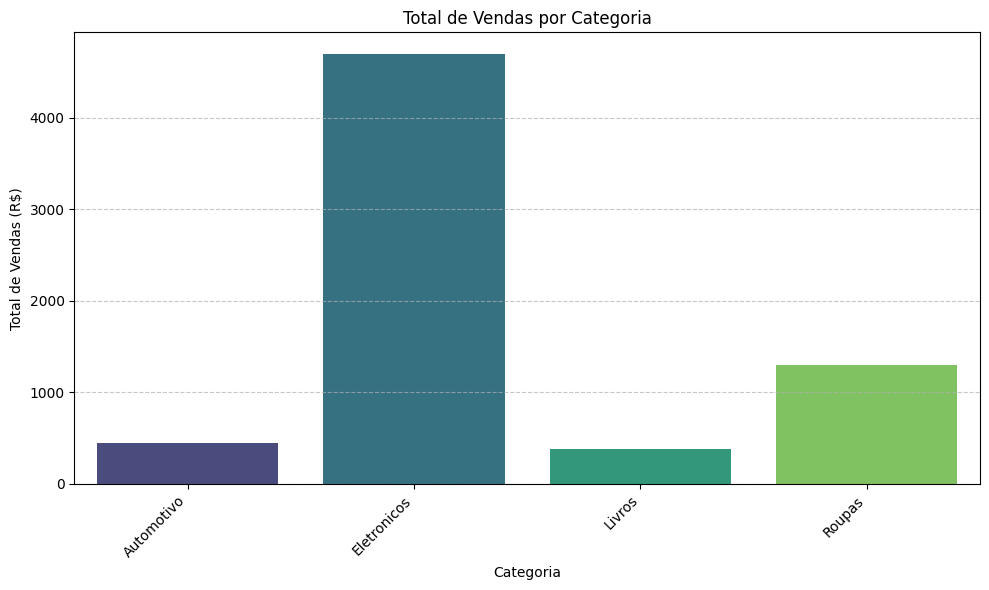

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por categoria e somar o valor
total_vendas_por_categoria = df_merged.groupby('categoria')['valor'].sum().reset_index()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='categoria', y='valor', data=total_vendas_por_categoria, palette='viridis')
plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas (R$)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()